In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

plt.style.use('seaborn-v0_8')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
data_dir = "/content/drive/MyDrive/Lung cancer/The IQ-OTHNCCD lung cancer dataset"

classes = ["Normal cases", "Bengin cases", "Malignant cases"]
print(classes)

['Normal cases', 'Bengin cases', 'Malignant cases']


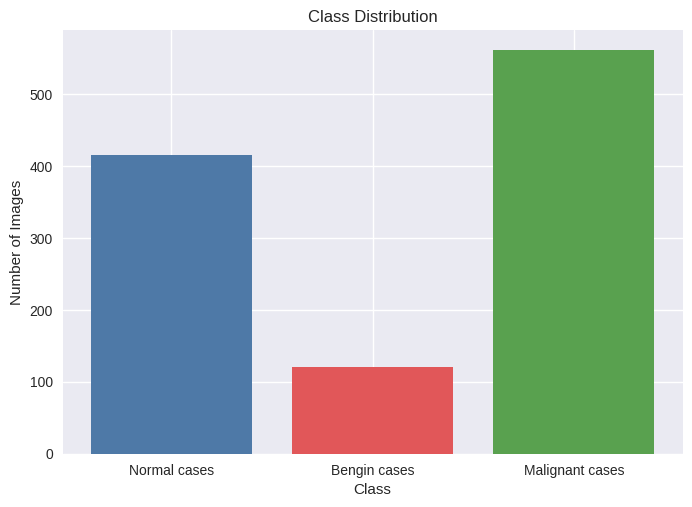

{'Normal cases': 416, 'Bengin cases': 120, 'Malignant cases': 561}


In [ ]:
class_counts = {}

for cls in classes:
    folder = os.path.join(data_dir, cls)
    class_counts[cls] = len(os.listdir(folder))

plt.bar(class_counts.keys(), class_counts.values(),
        color=['#4e79a7','#e15759','#59a14f'])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

print(class_counts)



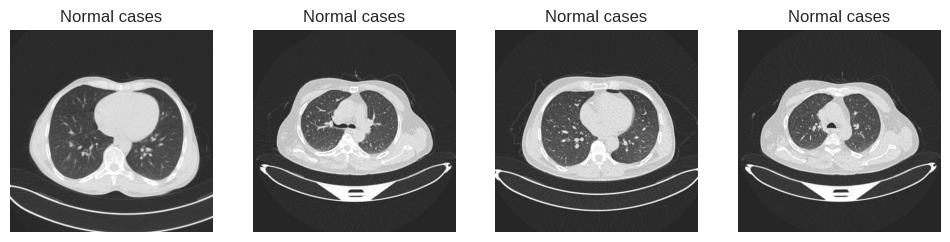

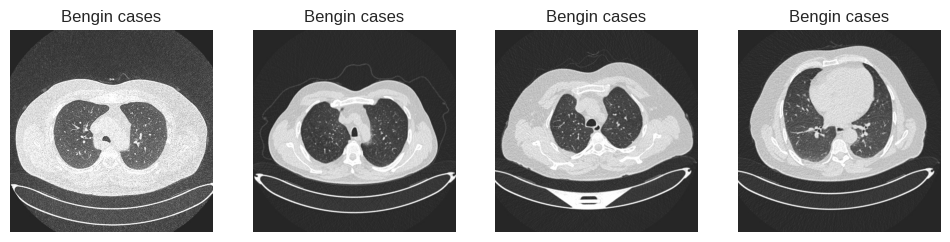

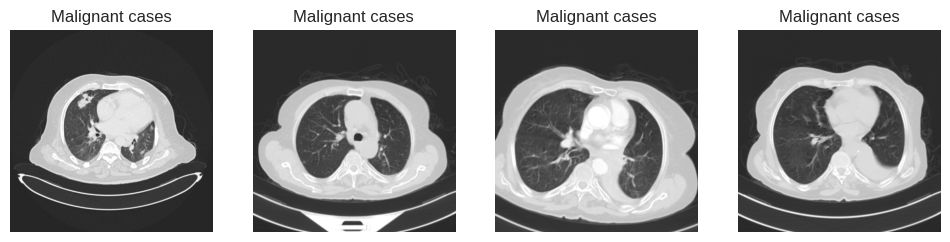

In [ ]:
def show_samples(class_name, n=4):

    folder = os.path.join(data_dir, class_name)
    images = os.listdir(folder)

    plt.figure(figsize=(12,4))

    for i in range(n):

        img = Image.open(os.path.join(folder, images[i]))

        plt.subplot(1,n,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis("off")

    plt.show()

for cls in classes:
    show_samples(cls)

In [ ]:
def create_dataloaders(image_size):

    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),

        transforms.RandomHorizontalFlip(),

        transforms.RandomRotation(15),

        transforms.RandomAffine(
            degrees=10,
            translate=(0.05, 0.05),
            scale=(0.9, 1.1)
        ),

        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    val_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),

        transforms.ToTensor(),

        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    # Load dataset
    dataset = datasets.ImageFolder(root=data_dir)

    # Train / validation split
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset,
                                              [train_size, val_size])

    # Apply transforms
    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform

    # DataLoaders
    train_loader = DataLoader(train_dataset,
                              batch_size=32,
                              shuffle=True,
                              num_workers=2)

    val_loader = DataLoader(val_dataset,
                            batch_size=32,
                            shuffle=False,
                            num_workers=2)

    return train_loader, val_loader, dataset

In [ ]:
dataset = datasets.ImageFolder(root=data_dir)

targets = [label for _,label in dataset.samples]

class_counts = Counter(targets)

total_samples = sum(class_counts.values())

class_weights = []

for i in range(len(class_counts)):
    class_weights.append(total_samples/class_counts[i])

class_weights = torch.tensor(class_weights).float().to(device)

print("Class weights:", class_weights)

Class weights: tensor([9.1417, 1.9554, 2.6370], device='cuda:0')


In [ ]:
train_loader_120, val_loader_120, dataset = create_dataloaders(120)

In [ ]:
class BaselineCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,3)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

In [ ]:
model1 = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model1.parameters(), lr=0.001)

print(model1)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [ ]:
def train_model(model,train_loader,val_loader,epochs=10):

    train_acc=[]
    val_acc=[]

    for epoch in range(epochs):

        model.train()
        correct=0
        total=0

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            _,preds=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(preds==labels).sum().item()

        train_accuracy=100*correct/total
        train_acc.append(train_accuracy)

        model.eval()
        correct=0
        total=0

        with torch.no_grad():

            for images,labels in val_loader:

                images=images.to(device)
                labels=labels.to(device)

                outputs=model(images)

                _,preds=torch.max(outputs,1)

                total+=labels.size(0)
                correct+=(preds==labels).sum().item()

        val_accuracy=100*correct/total
        val_acc.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs} | Train {train_accuracy:.2f}% | Val {val_accuracy:.2f}%")

    return train_acc,val_acc

In [ ]:
train_acc_120,val_acc_120 = train_model(
    model1,
    train_loader_120,
    val_loader_120,
    epochs=10
)

Epoch 1/10 | Train 32.16% | Val 34.55%
Epoch 2/10 | Train 42.08% | Val 40.45%
Epoch 3/10 | Train 44.13% | Val 40.00%
Epoch 4/10 | Train 49.03% | Val 53.18%
Epoch 5/10 | Train 47.09% | Val 34.55%
Epoch 6/10 | Train 40.94% | Val 40.45%
Epoch 7/10 | Train 49.60% | Val 53.18%
Epoch 8/10 | Train 50.51% | Val 40.91%
Epoch 9/10 | Train 48.00% | Val 59.09%
Epoch 10/10 | Train 53.02% | Val 53.18%


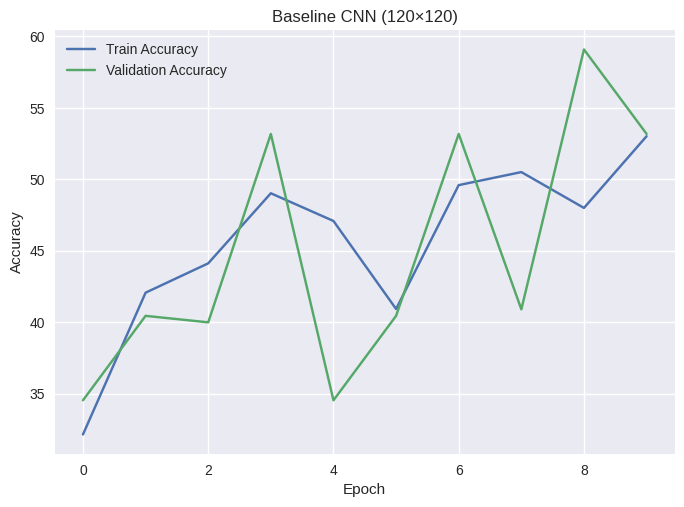

In [ ]:
plt.plot(train_acc_120,label="Train Accuracy")
plt.plot(val_acc_120,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN (120×120)")

plt.legend()
plt.show()

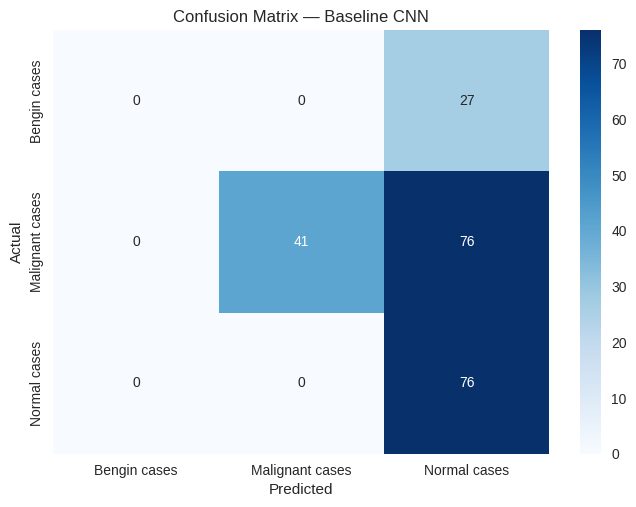

In [ ]:
model1.eval()

all_preds=[]
all_labels=[]

with torch.no_grad():

    for images,labels in val_loader_120:

        images=images.to(device)

        outputs=model1(images)

        _,preds=torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels,all_preds)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Baseline CNN")

plt.show()

In [ ]:
print(classification_report(all_labels,
                            all_preds,
                            target_names=dataset.classes))

                 precision    recall  f1-score   support

   Bengin cases       0.00      0.00      0.00        27
Malignant cases       1.00      0.35      0.52       117
   Normal cases       0.42      1.00      0.60        76

       accuracy                           0.53       220
      macro avg       0.47      0.45      0.37       220
   weighted avg       0.68      0.53      0.48       220



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Improved CNN

In [ ]:
train_loader_160, val_loader_160, dataset = create_dataloaders(160)

In [ ]:
class ImprovedCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,3)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

In [ ]:
model2 = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model2.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

print(model2)

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [ ]:
train_acc_160, val_acc_160 = train_model(
    model2,
    train_loader_160,
    val_loader_160,
    epochs=10
)

Epoch 1/10 | Train 63.06% | Val 50.91%
Epoch 2/10 | Train 81.64% | Val 65.45%
Epoch 3/10 | Train 81.41% | Val 61.36%
Epoch 4/10 | Train 82.90% | Val 39.55%
Epoch 5/10 | Train 85.18% | Val 67.27%
Epoch 6/10 | Train 87.00% | Val 40.00%
Epoch 7/10 | Train 86.77% | Val 75.00%
Epoch 8/10 | Train 87.12% | Val 56.36%
Epoch 9/10 | Train 88.03% | Val 65.91%
Epoch 10/10 | Train 89.62% | Val 85.91%


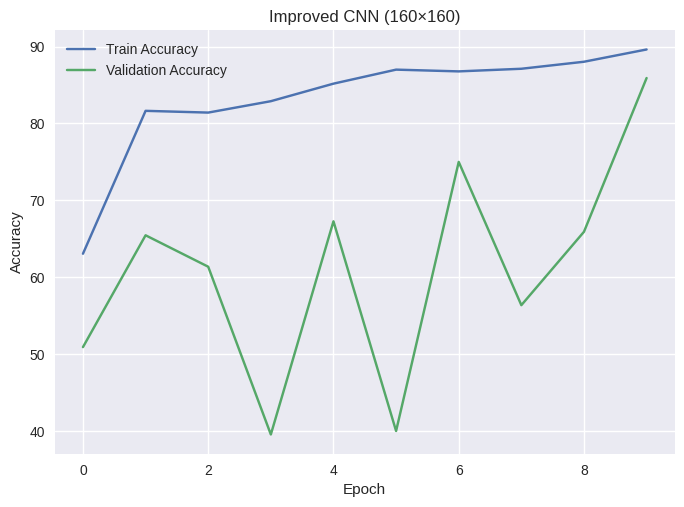

In [ ]:
plt.plot(train_acc_160,label="Train Accuracy")
plt.plot(val_acc_160,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN (160×160)")

plt.legend()
plt.show()

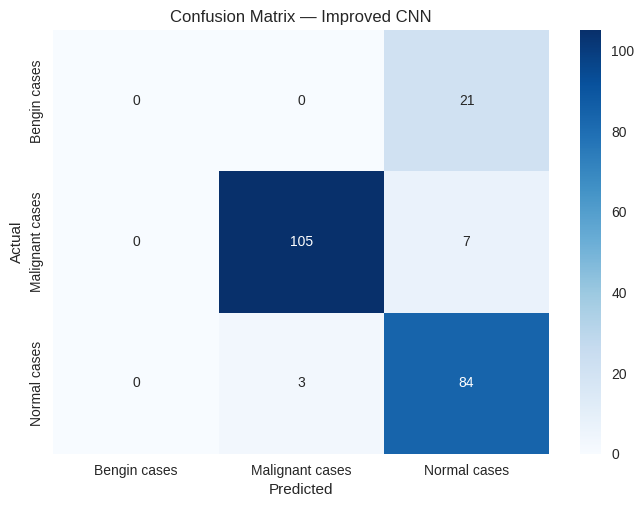

In [ ]:
model2.eval()

all_preds=[]
all_labels=[]

with torch.no_grad():

    for images,labels in val_loader_160:

        images=images.to(device)

        outputs=model2(images)

        _,preds=torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels,all_preds)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Improved CNN")

plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes
))

                 precision    recall  f1-score   support

   Bengin cases       0.00      0.00      0.00        21
Malignant cases       0.97      0.94      0.95       112
   Normal cases       0.75      0.97      0.84        87

       accuracy                           0.86       220
      macro avg       0.57      0.63      0.60       220
   weighted avg       0.79      0.86      0.82       220



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MODEL -3


In [ ]:
train_loader_224, val_loader_224, dataset = create_dataloaders(224)

In [ ]:
from torchvision import models

model3 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


In [ ]:
for param in model3.parameters():
    param.requires_grad = False

In [ ]:
num_features = model3.fc.in_features

model3.fc = nn.Linear(num_features, 3)

model3 = model3.to(device)

print(model3)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model3.fc.parameters(), lr=0.001)

In [ ]:
train_acc_224, val_acc_224 = train_model(
    model3,
    train_loader_224,
    val_loader_224,
    epochs=10
)

Epoch 1/10 | Train 63.97% | Val 74.09%
Epoch 2/10 | Train 82.44% | Val 81.36%
Epoch 3/10 | Train 84.95% | Val 84.55%
Epoch 4/10 | Train 84.38% | Val 86.36%
Epoch 5/10 | Train 88.37% | Val 85.91%
Epoch 6/10 | Train 86.89% | Val 86.36%
Epoch 7/10 | Train 89.05% | Val 87.73%
Epoch 8/10 | Train 89.74% | Val 88.18%
Epoch 9/10 | Train 91.45% | Val 89.55%
Epoch 10/10 | Train 90.65% | Val 88.18%


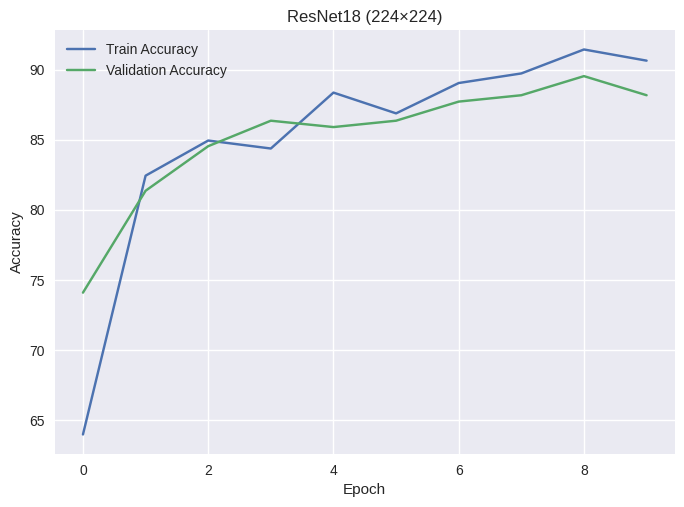

In [ ]:
plt.plot(train_acc_224,label="Train Accuracy")
plt.plot(val_acc_224,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 (224×224)")

plt.legend()
plt.show()

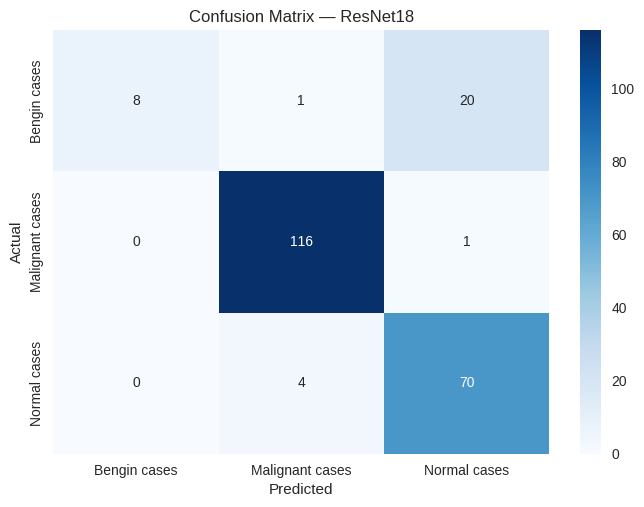

In [ ]:
model3.eval()

all_preds=[]
all_labels=[]

with torch.no_grad():

    for images,labels in val_loader_224:

        images=images.to(device)

        outputs=model3(images)

        _,preds=torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels,all_preds)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — ResNet18")

plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes
))

                 precision    recall  f1-score   support

   Bengin cases       1.00      0.28      0.43        29
Malignant cases       0.96      0.99      0.97       117
   Normal cases       0.77      0.95      0.85        74

       accuracy                           0.88       220
      macro avg       0.91      0.74      0.75       220
   weighted avg       0.90      0.88      0.86       220



MISSCLASIFIED IMAGES

In [ ]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

model3.eval()

with torch.no_grad():

    for images, labels in val_loader_224:

        images = images.to(device)

        outputs = model3(images)

        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):

            if preds[i] != labels[i]:

                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].cpu())
                misclassified_preds.append(preds[i].cpu())

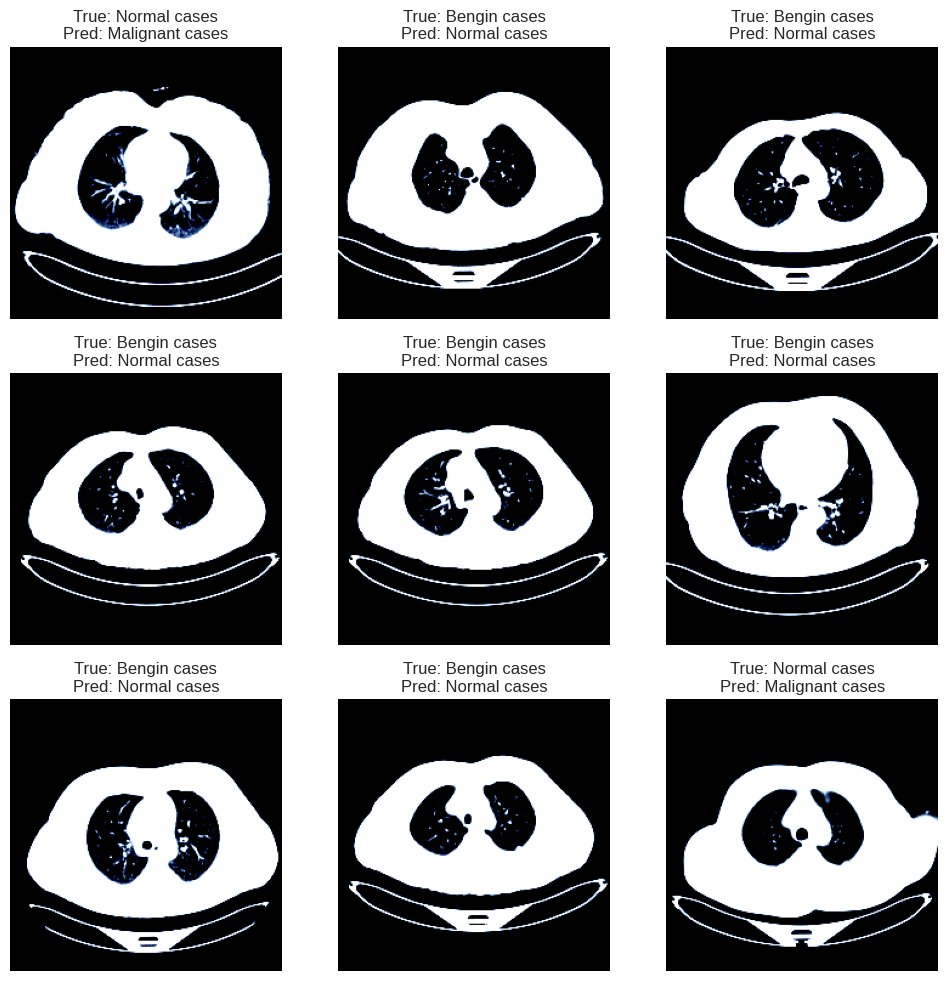

In [ ]:
import matplotlib.pyplot as plt

class_names = dataset.classes

num_images = min(9, len(misclassified_images))

plt.figure(figsize=(12,12))

for i in range(num_images):

    img = misclassified_images[i]

    img = img.permute(1,2,0).numpy()

    plt.subplot(3,3,i+1)
    plt.imshow(img)

    true_label = class_names[misclassified_labels[i]]
    pred_label = class_names[misclassified_preds[i]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.show()